In [1]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://archive.apache.org/dist/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys

import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F

spark= SparkSession.builder.appName("Mi primera").getOrCreate()

spark

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,513 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,738 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages 

In [2]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType

schema = StructType([
    StructField("track_id", StringType(), True),
    StructField("track_name", StringType(), True),
    StructField("track_artist", StringType(), True),
    StructField("track_popularity", IntegerType(), True),
    StructField("track_album_id", StringType(), True),
    StructField("track_album_name", StringType(), True),
    StructField("track_album_release_date", StringType(), True),
    StructField("playlist_name", StringType(), True),
    StructField("playlist_id", StringType(), True),
    StructField("playlist_genre", StringType(), True),
    StructField("playlist_subgenre", StringType(), True),
    StructField("danceability", FloatType(), True),
    StructField("energy", FloatType(), True),
    StructField("key", IntegerType(), True),
    StructField("loudness", FloatType(), True),
    StructField("mode", IntegerType(), True),
    StructField("speechiness", FloatType(), True),
    StructField("acousticness", FloatType(), True),
    StructField("instrumentalness", FloatType(), True),
    StructField("liveness", FloatType(), True),
    StructField("valence", FloatType(), True),
    StructField("tempo", FloatType(), True),
    StructField("duration_ms", IntegerType(), True),
])

In [3]:
df_schema = spark.read.csv('spotify_songs.csv', header = True, schema = schema)
df_schema.printSchema()

root
 |-- track_id: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_artist: string (nullable = true)
 |-- track_popularity: integer (nullable = true)
 |-- track_album_id: string (nullable = true)
 |-- track_album_name: string (nullable = true)
 |-- track_album_release_date: string (nullable = true)
 |-- playlist_name: string (nullable = true)
 |-- playlist_id: string (nullable = true)
 |-- playlist_genre: string (nullable = true)
 |-- playlist_subgenre: string (nullable = true)
 |-- danceability: float (nullable = true)
 |-- energy: float (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: float (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: float (nullable = true)
 |-- acousticness: float (nullable = true)
 |-- instrumentalness: float (nullable = true)
 |-- liveness: float (nullable = true)
 |-- valence: float (nullable = true)
 |-- tempo: float (nullable = true)
 |-- duration_ms: integer (nullable = true)



In [4]:
df_schema.show()

+--------------------+--------------------+----------------+----------------+--------------------+--------------------+------------------------+-------------+--------------------+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+
|            track_id|          track_name|    track_artist|track_popularity|      track_album_id|    track_album_name|track_album_release_date|playlist_name|         playlist_id|playlist_genre|playlist_subgenre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|
+--------------------+--------------------+----------------+----------------+--------------------+--------------------+------------------------+-------------+--------------------+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+
|6f807x0im

In [5]:
df_clean = df_schema[['playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'track_popularity']]

df_clean.show()

+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+
|playlist_genre|playlist_subgenre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|track_popularity|
+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+
|           pop|        dance pop|       0.748| 0.916|  6|  -2.634|   1|     0.0583|       0.102|             0.0|  0.0653|  0.518|122.036|     194754|              66|
|           pop|        dance pop|       0.726| 0.815| 11|  -4.969|   1|     0.0373|      0.0724|         0.00421|   0.357|  0.693| 99.972|     162600|              67|
|           pop|        dance pop|       0.675| 0.931|  1|  -3.432|   0|     0.0742|      0.0794|         2.33E-5|    0.11|  0.613|124.008|     176616|    

In [6]:
df_clean.printSchema()

root
 |-- playlist_genre: string (nullable = true)
 |-- playlist_subgenre: string (nullable = true)
 |-- danceability: float (nullable = true)
 |-- energy: float (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: float (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: float (nullable = true)
 |-- acousticness: float (nullable = true)
 |-- instrumentalness: float (nullable = true)
 |-- liveness: float (nullable = true)
 |-- valence: float (nullable = true)
 |-- tempo: float (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- track_popularity: integer (nullable = true)



In [7]:
df_clean.count()

32833

In [8]:
df_clean = df_clean.dropna()
df_clean.count()

32821

In [9]:
df_clean.describe('danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness').show()

+-------+-------------------+-------------------+------------------+------------------+------------------+-------------------+
|summary|       danceability|             energy|               key|          loudness|              mode|        speechiness|
+-------+-------------------+-------------------+------------------+------------------+------------------+-------------------+
|  count|              32821|              32821|             32821|             32821|             32821|              32821|
|   mean| 0.6548413911806608| 0.6987285737984427|5.3754608330032605|-6.717942109486704|0.5656439474726547|0.10705184796437721|
| stddev|0.14508082923345447|0.18084723273000877| 3.611698931232073| 2.987750507689067|0.4956796931193943|0.10126262330917422|
|    min|                0.0|            1.75E-4|                 0|           -46.448|                 0|                0.0|
|    max|              0.983|                1.0|                11|             1.275|                 1|     

In [10]:
df_clean.describe('acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'track_popularity').show()

+-------+-------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+
|summary|       acousticness|   instrumentalness|           liveness|           valence|             tempo|       duration_ms|  track_popularity|
+-------+-------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+
|  count|              32821|              32821|              32821|             32821|             32821|             32821|             32821|
|   mean|0.17531858269113598|0.08474072722271873|0.19020800464872142|0.5105593810668403|120.87279819558145|225763.93223850583|42.485573261021905|
| stddev| 0.2196408186632955| 0.2242422580301144|0.15433586676543395|0.2331380966745143| 26.89980501426482| 59792.12342445556|24.980254492938275|
|    min|                0.0|                0.0|                0.0|               0.0|               0.0|              400

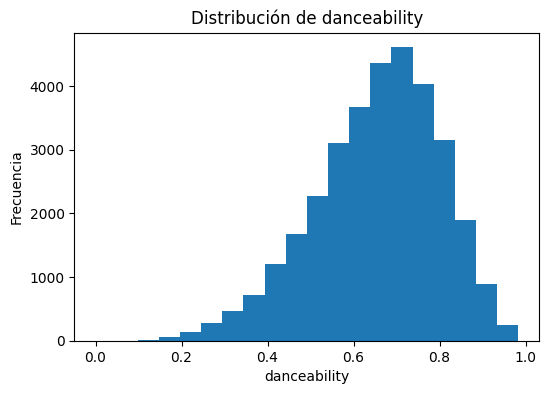

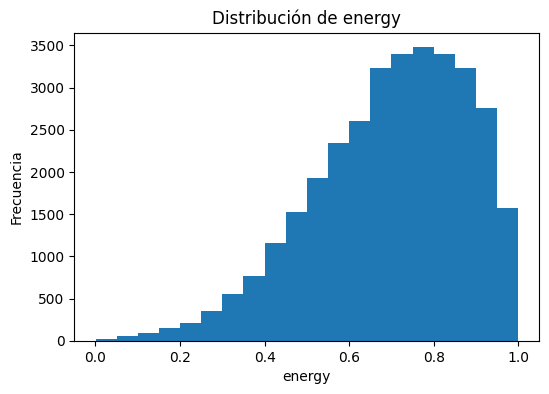

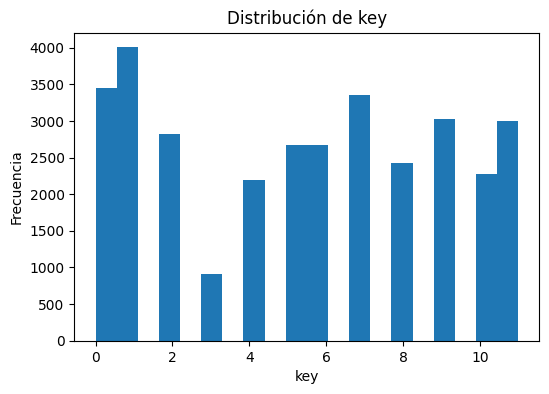

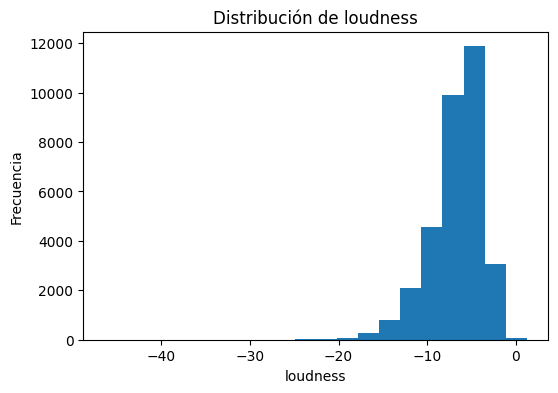

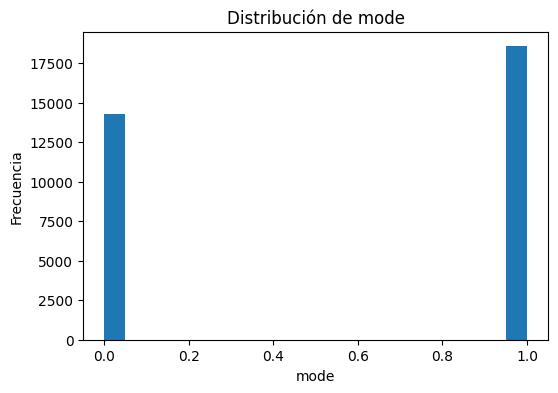

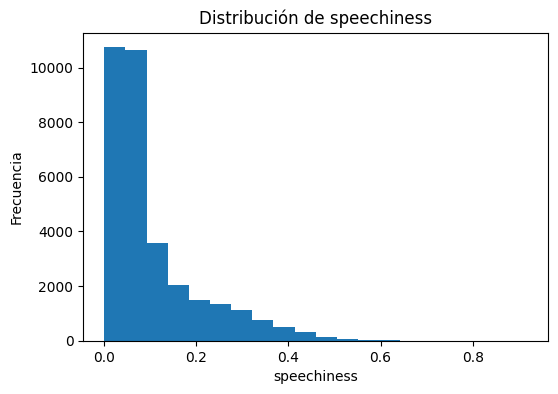

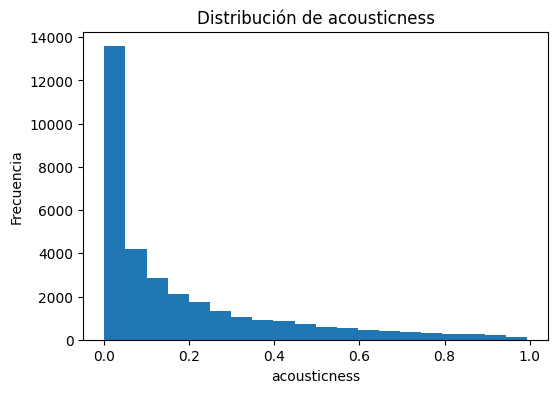

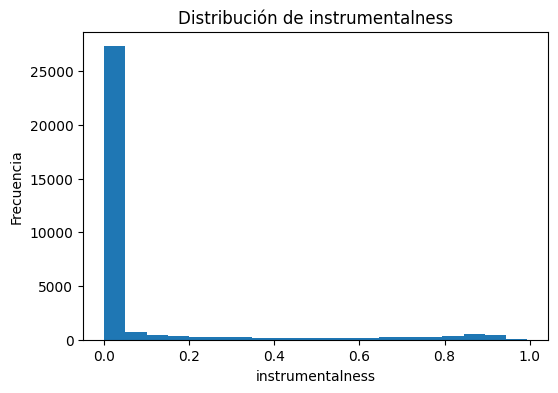

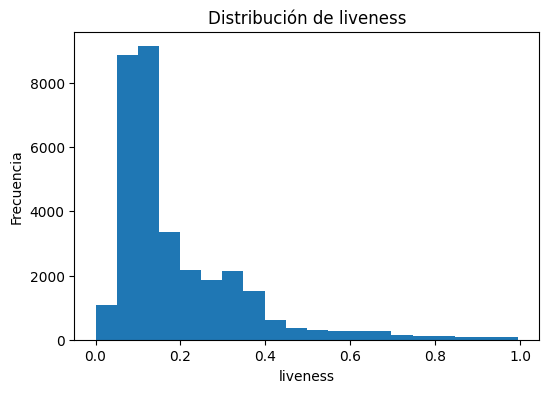

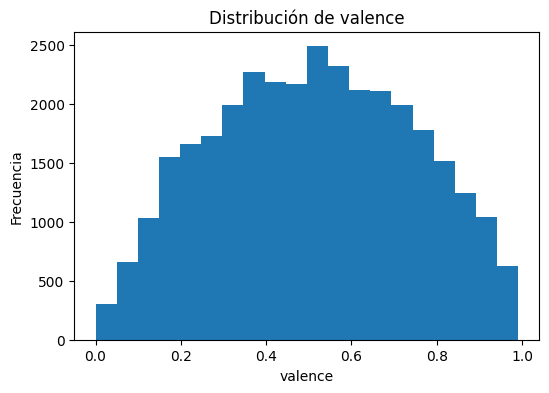

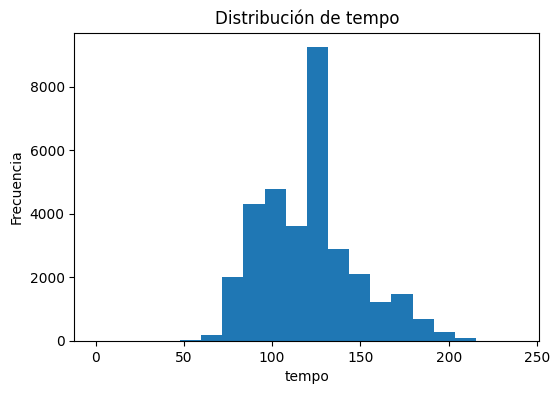

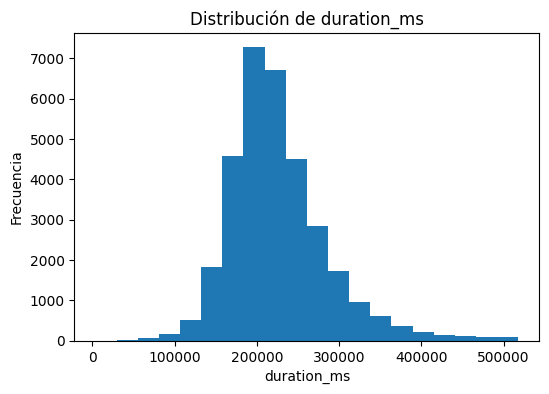

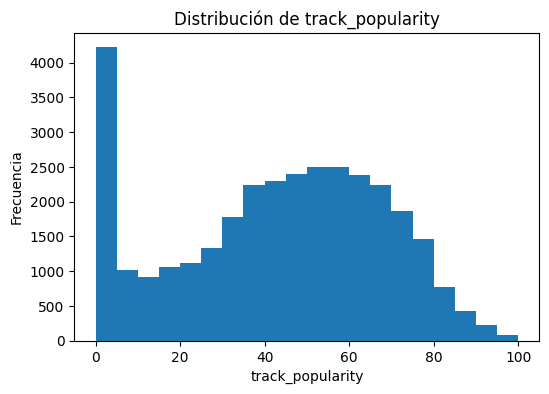

In [11]:
import matplotlib.pyplot as plt

numeric_cols = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
                'duration_ms', 'track_popularity']

for col in numeric_cols:
    data = df_clean.select(col).collect()
    values = [row[col] for row in data]

    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=20)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de {col}")
    plt.show()

In [12]:
from pyspark.sql.functions import monotonically_increasing_id

df_clean = df_clean.withColumn("index", monotonically_increasing_id())
df_clean.show()

+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+
|playlist_genre|playlist_subgenre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|track_popularity|index|
+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+
|           pop|        dance pop|       0.748| 0.916|  6|  -2.634|   1|     0.0583|       0.102|             0.0|  0.0653|  0.518|122.036|     194754|              66|    0|
|           pop|        dance pop|       0.726| 0.815| 11|  -4.969|   1|     0.0373|      0.0724|         0.00421|   0.357|  0.693| 99.972|     162600|              67|    1|
|           pop|        dance pop|       0.675| 0.931|  1|  -3.432|   0|     0.0742|      0.0794|         2.33E-5|    0.11|  

In [13]:
from pyspark.sql.functions import when

df_clean = df_clean.withColumn(
    "hit",
    when(df_clean.track_popularity > 75, 1).otherwise(0)
)

df_clean.show()

+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+---+
|playlist_genre|playlist_subgenre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|track_popularity|index|hit|
+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+---+
|           pop|        dance pop|       0.748| 0.916|  6|  -2.634|   1|     0.0583|       0.102|             0.0|  0.0653|  0.518|122.036|     194754|              66|    0|  0|
|           pop|        dance pop|       0.726| 0.815| 11|  -4.969|   1|     0.0373|      0.0724|         0.00421|   0.357|  0.693| 99.972|     162600|              67|    1|  0|
|           pop|        dance pop|       0.675| 0.931|  1|  -3.432|   0|     0.0742|      0.0794|        

In [14]:
df_clean.select('playlist_genre').distinct().show()

+--------------+
|playlist_genre|
+--------------+
|           r&b|
|           pop|
|           rap|
|          rock|
|         latin|
|           edm|
+--------------+



In [15]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol = "playlist_genre", outputCol = "genre index")
df_clean = indexer.fit(df_clean).transform(df_clean)
df_clean.show()

+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+---+-----------+
|playlist_genre|playlist_subgenre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|track_popularity|index|hit|genre index|
+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+---+-----------+
|           pop|        dance pop|       0.748| 0.916|  6|  -2.634|   1|     0.0583|       0.102|             0.0|  0.0653|  0.518|122.036|     194754|              66|    0|  0|        2.0|
|           pop|        dance pop|       0.726| 0.815| 11|  -4.969|   1|     0.0373|      0.0724|         0.00421|   0.357|  0.693| 99.972|     162600|              67|    1|  0|        2.0|
|           pop|        dance pop|       0.67

In [16]:
df_clean.select('playlist_genre','genre index').distinct().sort('genre index').show()

+--------------+-----------+
|playlist_genre|genre index|
+--------------+-----------+
|           edm|        0.0|
|           rap|        1.0|
|           pop|        2.0|
|           r&b|        3.0|
|         latin|        4.0|
|          rock|        5.0|
+--------------+-----------+



In [17]:
from pyspark.ml.feature import VectorAssembler

In [18]:
inputCols = [
              'energy',
              'key',
              'loudness',
              'mode',
              'speechiness',
              'acousticness',
              'instrumentalness',
              'liveness',
              'valence',
              'tempo',
              'duration_ms',
              'danceability',
              'track_popularity',
              #'hit'
              #'playlist_genre',
              #'playlist_subgenre',
              ]

assembler = VectorAssembler(inputCols = inputCols, outputCol = "features")
df_with_features = assembler.transform(df_clean)

df_with_features.select('features').show(10, False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.9160000085830688,6.0,-2.634000062942505,1.0,0.05829999968409538,0.10199999809265137,0.0,0.06530000269412994,0.5180000066757202,122.03600311279297,194754.0,0.7480000257492065,66.0]                  |
|[0.8149999976158142,11.0,-4.968999862670898,1.0,0.037300001829862595,0.07240000367164612,0.004209999926388264,0.3569999933242798,0.6930000185966492,99.97200012207031,162600.0,0.7260000109

In [19]:
from pyspark.ml.feature import StandardScaler

In [20]:
scaler = StandardScaler(inputCol="features", outputCol="features_scaled")
df_escalado = scaler.fit(df_with_features).transform(df_with_features)
df_escalado.select('features_scaled').show(10, False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                                                                                                                                                       |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[5.065048520541022,1.6612680387379881,-0.8815997373822967,2.017431849400232,0.5757306869889609,0.4643945452098088,0.0,0.42310322326679656,2.221859121544188,4.536687275170875,3.257184873958561,5.155746832309437,2.642086773721921]                  |
|[4.

In [21]:
from pyspark.ml.feature import VarianceThresholdSelector, ChiSqSelector

In [22]:
selector = VarianceThresholdSelector(varianceThreshold=0, outputCol="selected_features")

df_sel = selector.fit(df_escalado).transform(df_escalado)
df_sel.select('selected_features').show(10, False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|selected_features                                                                                                                                                                                       |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.9160000085830688,6.0,-2.634000062942505,1.0,0.05829999968409538,0.10199999809265137,0.0,0.06530000269412994,0.5180000066757202,122.03600311279297,194754.0,0.7480000257492065,66.0]                  |
|[0.8149999976158142,11.0,-4.968999862670898,1.0,0.037300001829862595,0.07240000367164612,0.004209999926388264,0.3569999933242798,0.6930000185966492,99.97200012207031,162600.0,0.7260000109

In [23]:
df_sel.show()

+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+---+-----------+--------------------+--------------------+--------------------+
|playlist_genre|playlist_subgenre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|track_popularity|index|hit|genre index|            features|     features_scaled|   selected_features|
+--------------+-----------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+----------------+-----+---+-----------+--------------------+--------------------+--------------------+
|           pop|        dance pop|       0.748| 0.916|  6|  -2.634|   1|     0.0583|       0.102|             0.0|  0.0653|  0.518|122.036|     194754|              66|    0|  0|        2.0|[0.91600000858306...|[5.06504852054102...|[0.916

In [24]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import DecisionTreeClassifier

In [36]:
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from math import sqrt

In [40]:
# Random Forest
train_data, test_data = df_sel.randomSplit([0.7, 0.3])

# Train the model
rf = RandomForestClassifier(featuresCol="selected_features", labelCol="genre index")
model = rf.fit(train_data)

# Predictions
predictions = model.transform(test_data)
predictions.select("prediction", "genre index").show()

# Evaluar el modelo
predictions = model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="genre index", predictionCol="prediction",
                                              metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
accuracy

+----------+-----------+
|prediction|genre index|
+----------+-----------+
|       5.0|        4.0|
|       3.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       1.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       1.0|        4.0|
|       5.0|        4.0|
|       3.0|        4.0|
|       1.0|        4.0|
|       3.0|        4.0|
|       1.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       1.0|        4.0|
|       1.0|        4.0|
|       2.0|        4.0|
|       0.0|        4.0|
|       1.0|        4.0|
+----------+-----------+
only showing top 20 rows



0.47300638780136

In [41]:
mae(predictions.select('prediction').collect(), predictions.select('genre index').collect())

1.1976097259427159

In [42]:
sqrt(mse(predictions.select('prediction').collect(), predictions.select('genre index').collect()))

1.8450148916867999

In [26]:
predictions.groupBy("genre index").mean("prediction").show()

+-----------+------------------+
|genre index|   avg(prediction)|
+-----------+------------------+
|        1.0|1.5602240896358543|
|        4.0| 2.456975228161669|
|        3.0| 2.566811684275948|
|        2.0|2.5301062573789848|
|        5.0| 3.943396226415094|
|        0.0|0.9569327731092437|
+-----------+------------------+



In [27]:
# Decision tree
train_data, test_data = df_sel.randomSplit([0.7, 0.3])

# Train the model
dt = DecisionTreeClassifier(featuresCol="selected_features", labelCol="genre index")
model = rf.fit(train_data)

# Predictions
predictions = model.transform(test_data)
predictions.select("prediction", "genre index").show()

# Evaluar el modelo
predictions = model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="genre index", predictionCol="prediction",
                                              metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
accuracy

+----------+-----------+
|prediction|genre index|
+----------+-----------+
|       3.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       1.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       0.0|        4.0|
|       5.0|        4.0|
|       3.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       2.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       1.0|        4.0|
|       5.0|        4.0|
|       5.0|        4.0|
|       3.0|        4.0|
|       1.0|        4.0|
+----------+-----------+
only showing top 20 rows



0.4738943488943489

In [38]:
mae(predictions.select('prediction').collect(), predictions.select('genre index').collect())

1.217035217035217

In [39]:
sqrt(mse(predictions.select('prediction').collect(), predictions.select('genre index').collect()))

1.8776019347532173